# 📈 Multi-Stock ML Prediction Dashboard
**Dataset:** Multi_Stock_SMA_Dashboard_Dataset.csv  
**Model:** Gradient Boosting Regressor  
**Stocks:** AAPL, MSFT, GOOGL, AMZN, TSLA, META, NVDA, NFLX, JPM, JNJ, XOM, WMT  
**Goal:** Predict next 5-day closing prices for each stock


## 1. Install & Import Libraries

In [1]:
# # Install required libraries if not already present
# !pip install scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Load & Clean Data

In [3]:
# Load dataset - update path if needed
df = pd.read_csv('Multi_Stock_SMA_Dashboard_Dataset.csv', skiprows=1)
df.columns = ['Date','AAPL','MSFT','GOOGL','AMZN','TSLA','META','NVDA','NFLX','JPM','JNJ','XOM','WMT']
df = df.dropna()

# Remove $ signs and commas, convert to float
for col in df.columns[1:]:
    df[col] = df[col].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip().astype(float)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
df.head()

Dataset shape: (252, 13)
Date range: 2024-01-02 → 2024-12-18


,Date,AAPL,MSFT,GOOGL,AMZN,TSLA,META,NVDA,NFLX,JPM,JNJ,XOM,WMT
0,2024-01-02,182.00,378.00,172.00,190.00,240.00,480.00,870.00,620.00,198.00,155.00,112.00,168.00
1,2024-01-03,183.21,382.41,171.79,187.50,231.29,471.96,895.21,625.52,196.96,155.29,113.73,168.44
2,2024-01-04,180.46,388.19,172.45,185.03,234.38,482.22,916.74,625.33,196.19,155.96,115.63,170.50
3,2024-01-05,180.95,392.32,174.76,184.19,228.25,484.29,941.92,637.59,194.36,154.56,117.60,171.86
4,2024-01-08,178.39,396.97,174.52,185.67,233.90,482.56,969.82,643.39,196.85,152.78,116.14,171.76


In [4]:
# Summary statistics
df.describe().round(2)

,Date,AAPL,MSFT,GOOGL,AMZN,TSLA,META,NVDA,NFLX,JPM,JNJ,XOM,WMT
count,252,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00
mean,2024-06-25 07:14:17.142857216,179.36,466.52,193.77,191.22,343.01,459.08,1136.08,862.17,199.71,146.46,127.48,163.47
min,2024-01-02 00:00:00,165.07,378.00,171.79,164.36,223.78,379.95,870.00,620.00,178.29,136.94,112.00,153.72
25%,2024-03-28 18:00:00,172.44,414.86,186.81,180.55,302.02,426.90,1019.37,695.36,189.46,142.78,122.88,160.95
50%,2024-06-25 12:00:00,177.40,458.23,193.60,192.36,340.63,459.83,1082.22,858.03,203.32,145.64,126.12,164.20
75%,2024-09-20 18:00:00,183.18,523.35,200.66,201.26,368.80,489.44,1251.93,1040.62,207.97,150.91,130.06,166.48
max,2024-12-18 00:00:00,212.02,544.98,221.72,218.34,511.93,533.57,1485.87,1129.91,214.59,155.96,145.52,171.91
std,NaN,9.66,53.27,10.30,13.23,65.84,38.83,144.22,172.41,9.79,4.84,6.79,4.30


## 3. Exploratory Data Analysis (EDA)

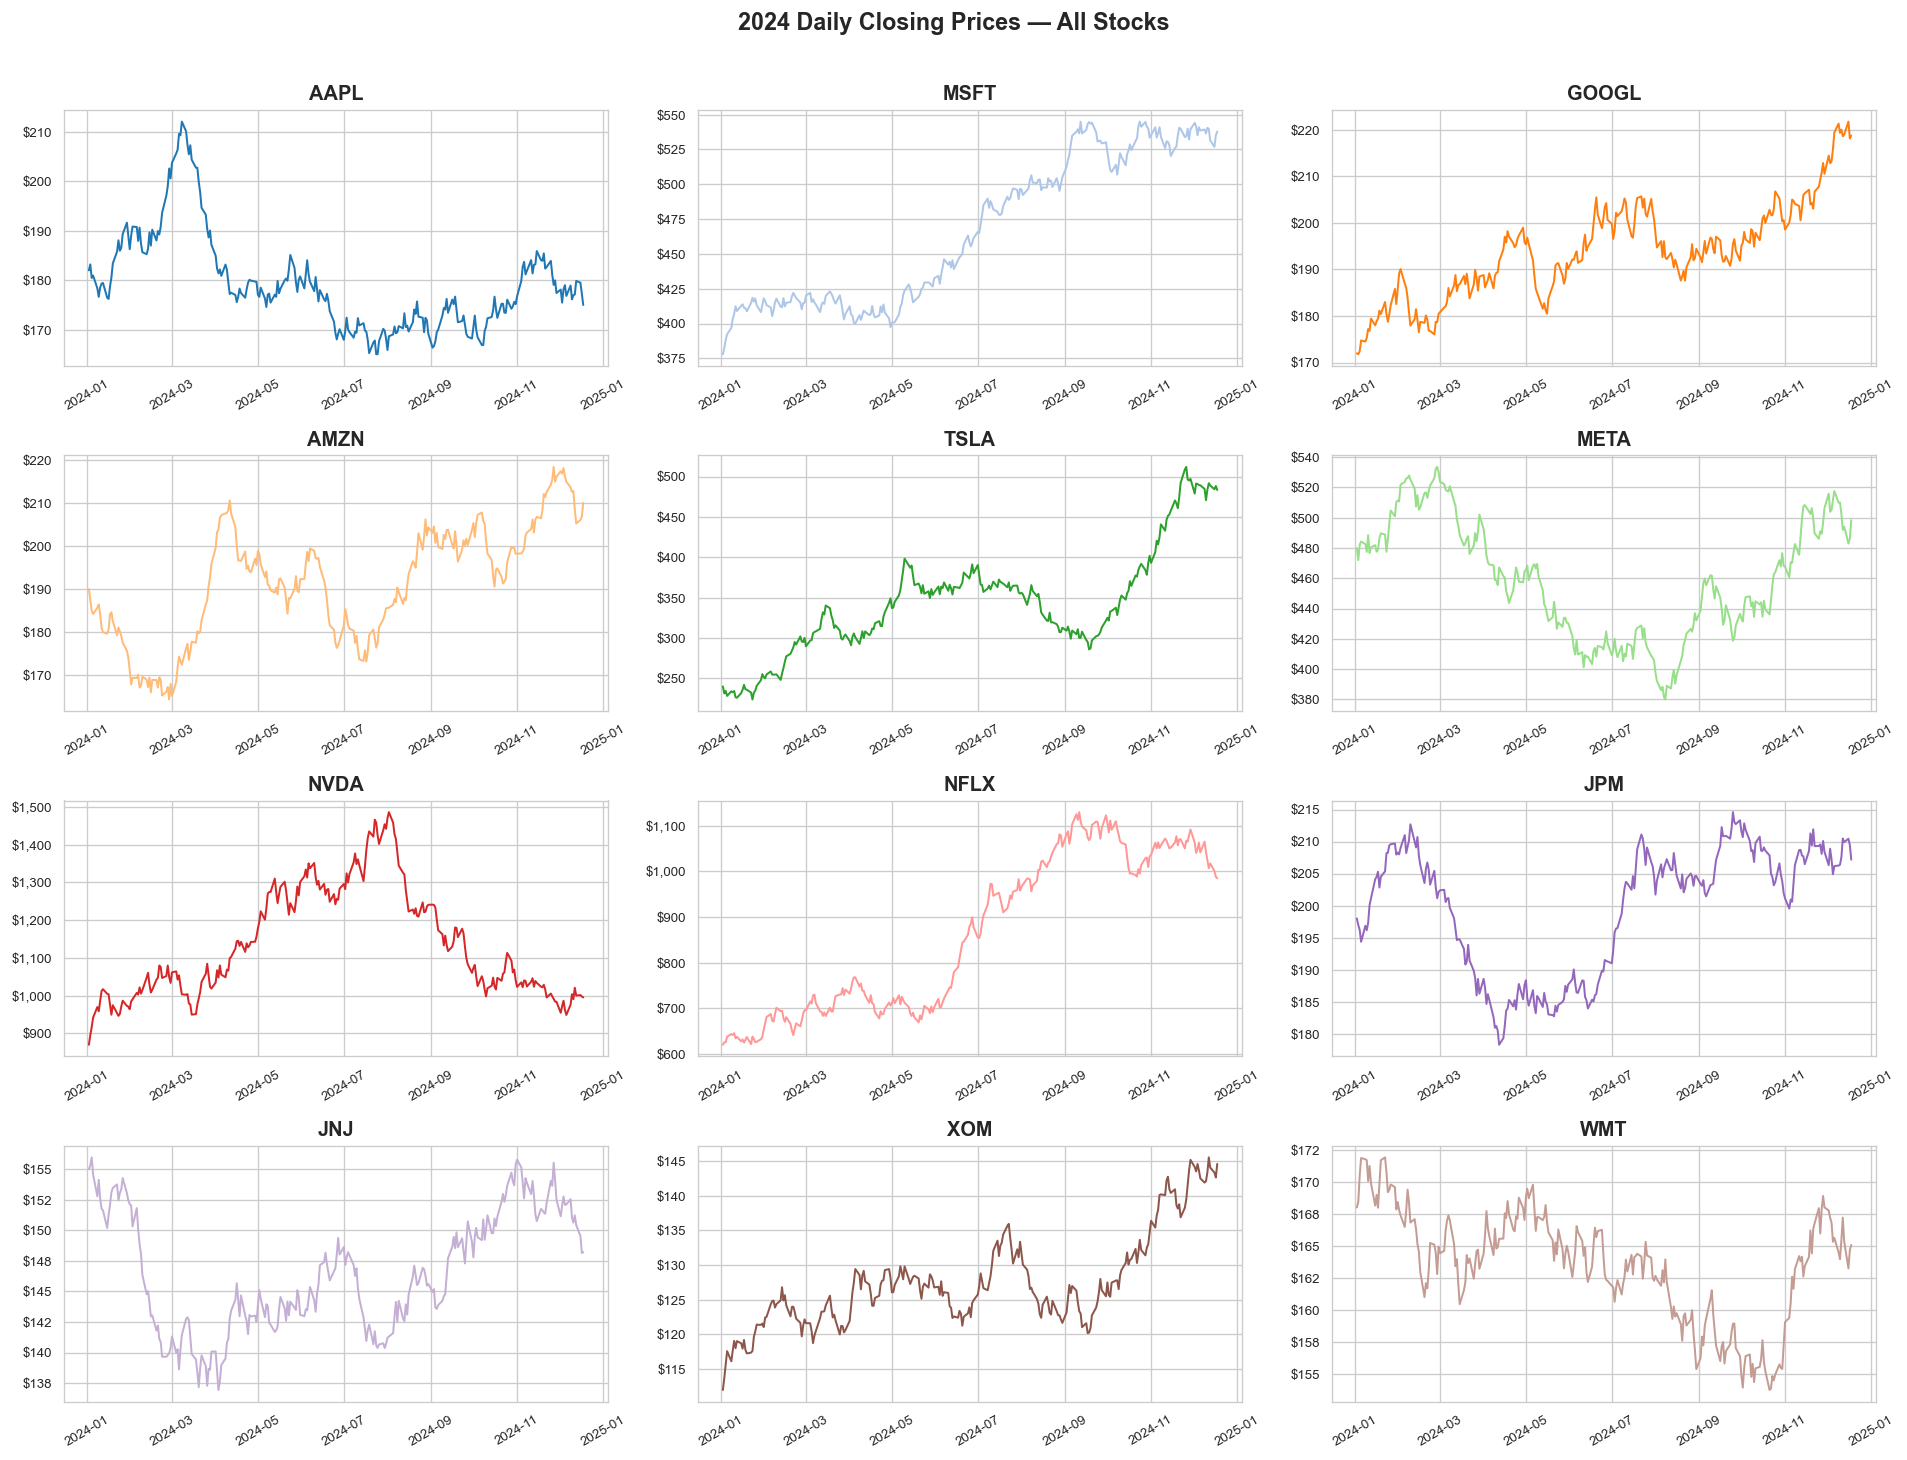

In [5]:
stocks = ['AAPL','MSFT','GOOGL','AMZN','TSLA','META','NVDA','NFLX','JPM','JNJ','XOM','WMT']

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()
colors = plt.cm.tab20.colors

for i, stock in enumerate(stocks):
    ax = axes[i]
    ax.plot(df['Date'], df[stock], color=colors[i], linewidth=1.2)
    ax.set_title(stock, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('2024 Daily Closing Prices — All Stocks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

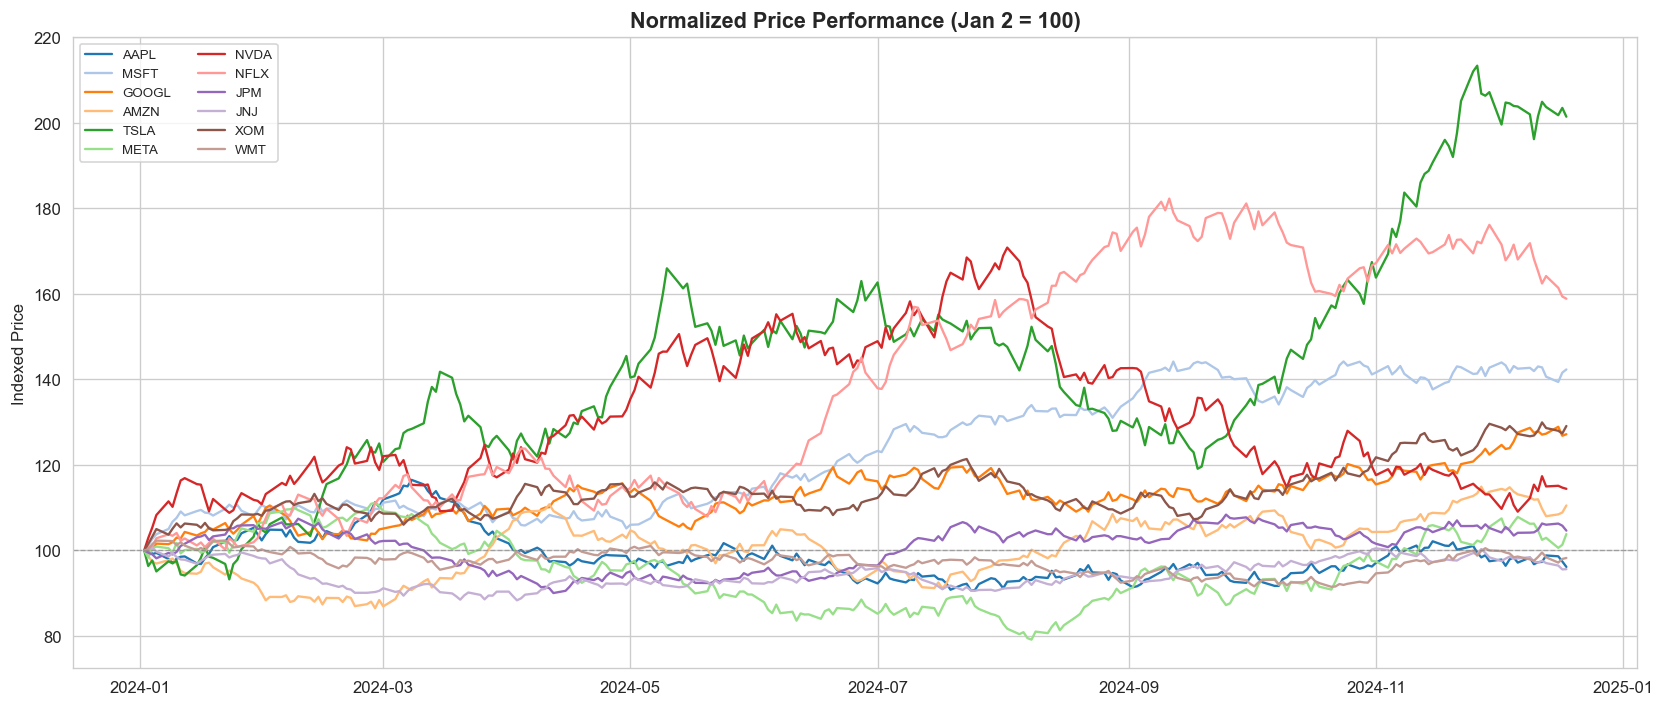

In [6]:
# Normalized price performance (base = 100)
fig, ax = plt.subplots(figsize=(14, 6))
for i, stock in enumerate(stocks):
    normalized = (df[stock] / df[stock].iloc[0]) * 100
    ax.plot(df['Date'], normalized, label=stock, linewidth=1.4, color=colors[i])

ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Normalized Price Performance (Jan 2 = 100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Indexed Price')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

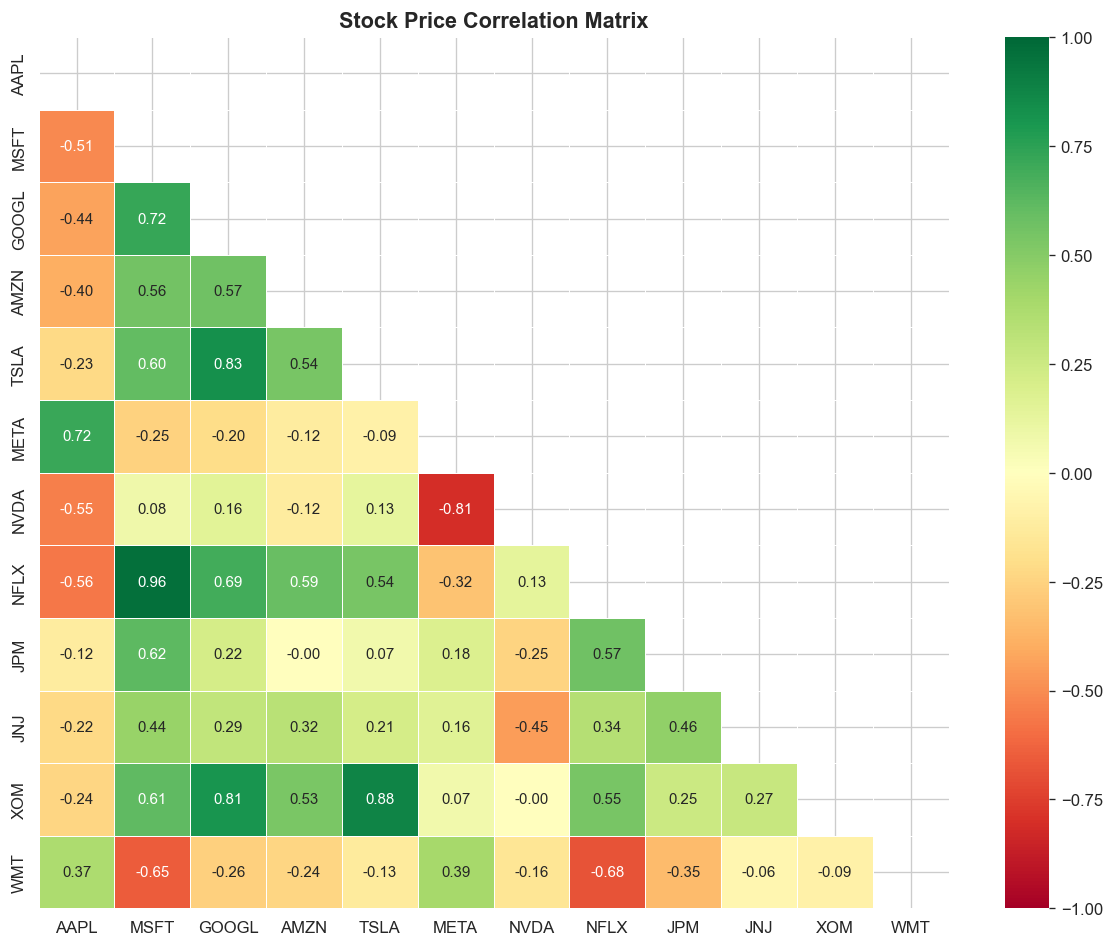

In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[stocks].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Stock Price Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [8]:
def make_features(series, lookback=10):
    """
    Build feature matrix from price series.
    Features:
      - Last 10 closing prices (lookback window)
      - SMA-10, SMA-20, SMA-50
      - 10-day momentum (absolute & percent)
    """
    X, y = [], []
    for i in range(lookback, len(series)):
        window = series[i - lookback:i]
        feat = list(window)
        feat.append(np.mean(window))                          # SMA-10
        feat.append(np.mean(series[max(0, i-20):i]))          # SMA-20
        feat.append(np.mean(series[max(0, i-50):i]))          # SMA-50
        feat.append(window[-1] - window[0])                   # Momentum (abs)
        feat.append(window[-1] / window[0] - 1)               # Momentum (%)
        X.append(feat)
        y.append(series[i])
    return np.array(X), np.array(y)

print('✅ Feature engineering function defined')
print('Features per sample: 15 (10 lag prices + SMA10 + SMA20 + SMA50 + momentum_abs + momentum_pct)')

✅ Feature engineering function defined
Features per sample: 15 (10 lag prices + SMA10 + SMA20 + SMA50 + momentum_abs + momentum_pct)


## 5. Model Training — Gradient Boosting Regressor

In [9]:
LOOKBACK = 10
results = {}

for stock in stocks:
    series = df[stock].values
    X, y = make_features(series, lookback=LOOKBACK)

    # 80/20 train-test split (time-ordered)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Train Gradient Boosting model
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    # 5-day future forecast (iterative rollout)
    window = list(series[-LOOKBACK:])
    all_vals = series.tolist()
    future_preds = []
    for _ in range(5):
        feat = window[-LOOKBACK:]
        hist = all_vals + future_preds
        f = list(feat)
        f.append(np.mean(feat))
        f.append(np.mean(hist[-20:]))
        f.append(np.mean(hist[-50:]))
        f.append(feat[-1] - feat[0])
        f.append(feat[-1] / feat[0] - 1)
        nxt = model.predict([f])[0]
        future_preds.append(nxt)
        window.append(nxt)

    current_price = series[-1]
    pred_5day     = future_preds[-1]
    change_pct    = (pred_5day - current_price) / current_price * 100
    signal        = 'BUY' if change_pct > 1 else ('SELL' if change_pct < -1 else 'HOLD')

    results[stock] = {
        'model': model,
        'y_test': y_test,
        'y_pred': y_pred,
        'current': current_price,
        'next5': future_preds,
        'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape,
        'change_pct': change_pct, 'signal': signal
    }
    print(f'{stock:5s} | MAE={mae:6.2f} | RMSE={rmse:6.2f} | R²={r2:+.3f} | MAPE={mape:5.2f}% | Signal: {signal}')

print('\n✅ All models trained successfully')

AAPL  | MAE=  3.21 | RMSE=  3.87 | R²=-0.041 | MAPE= 1.78% | Signal: SELL
MSFT  | MAE=  4.32 | RMSE=  5.29 | R²=+0.456 | MAPE= 0.81% | Signal: SELL
GOOGL | MAE=  5.98 | RMSE=  8.43 | R²=-0.365 | MAPE= 2.79% | Signal: SELL
AMZN  | MAE=  5.31 | RMSE=  6.96 | R²=+0.305 | MAPE= 2.52% | Signal: SELL
TSLA  | MAE= 65.05 | RMSE= 79.95 | R²=-1.498 | MAPE=13.74% | Signal: SELL
META  | MAE= 11.87 | RMSE= 13.96 | R²=+0.653 | MAPE= 2.43% | Signal: BUY
NVDA  | MAE= 17.87 | RMSE= 21.73 | R²=+0.593 | MAPE= 1.74% | Signal: BUY
NFLX  | MAE= 42.07 | RMSE= 52.99 | R²=-2.380 | MAPE= 4.13% | Signal: BUY
JPM   | MAE=  1.72 | RMSE=  1.98 | R²=+0.550 | MAPE= 0.83% | Signal: BUY
JNJ   | MAE=  1.84 | RMSE=  2.41 | R²=-0.863 | MAPE= 1.20% | Signal: SELL
XOM   | MAE=  6.40 | RMSE=  7.62 | R²=-1.325 | MAPE= 4.53% | Signal: SELL
WMT   | MAE=  2.27 | RMSE=  2.77 | R²=+0.664 | MAPE= 1.38% | Signal: SELL

✅ All models trained successfully


## 6. Model Performance Summary

In [10]:
# Build summary dataframe
summary = pd.DataFrame([
    {
        'Stock': s,
        'Current Price ($)': round(results[s]['current'], 2),
        'MAE': round(results[s]['mae'], 2),
        'RMSE': round(results[s]['rmse'], 2),
        'R²': round(results[s]['r2'], 3),
        'MAPE (%)': round(results[s]['mape'], 2),
        '5d Forecast ($)': round(results[s]['next5'][-1], 2),
        'Change (%)': round(results[s]['change_pct'], 2),
        'Signal': results[s]['signal']
    } for s in stocks
])

def color_signal(val):
    if val == 'BUY':  return 'background-color: #d4edda; color: #155724; font-weight: bold'
    if val == 'SELL': return 'background-color: #f8d7da; color: #721c24; font-weight: bold'
    return 'background-color: #fff3cd; color: #856404; font-weight: bold'

def color_change(val):
    if val > 0:  return 'color: #155724; font-weight: bold'
    if val < 0:  return 'color: #721c24; font-weight: bold'
    return ''

summary.style \
    .applymap(color_signal, subset=['Signal']) \
    .applymap(color_change, subset=['Change (%)']) \
    .format({'Current Price ($)': '${:.2f}', '5d Forecast ($)': '${:.2f}', 'Change (%)': '{:+.2f}%'})

,Stock,Current Price ($),MAE,RMSE,R²,MAPE (%),5d Forecast ($),Change (%),Signal
0,AAPL,$175.01,3.210000,3.870000,-0.041000,1.780000,$171.62,-1.94%,SELL
1,MSFT,$537.93,4.320000,5.290000,0.456000,0.810000,$525.73,-2.27%,SELL
2,GOOGL,$218.73,5.980000,8.430000,-0.365000,2.790000,$202.73,-7.32%,SELL
3,AMZN,$209.98,5.310000,6.960000,0.305000,2.520000,$194.31,-7.46%,SELL
4,TSLA,$483.32,65.050000,79.950000,-1.498000,13.740000,$363.60,-24.77%,SELL
5,META,$498.37,11.870000,13.960000,0.653000,2.430000,$514.47,+3.23%,BUY
6,NVDA,$995.33,17.870000,21.730000,0.593000,1.740000,$1030.31,+3.51%,BUY
7,NFLX,$984.80,42.070000,52.990000,-2.380000,4.130000,$1070.67,+8.72%,BUY
8,JPM,$207.17,1.720000,1.980000,0.550000,0.830000,$210.74,+1.72%,BUY
9,JNJ,$148.22,1.840000,2.410000,-0.863000,1.200000,$144.21,-2.70%,SELL


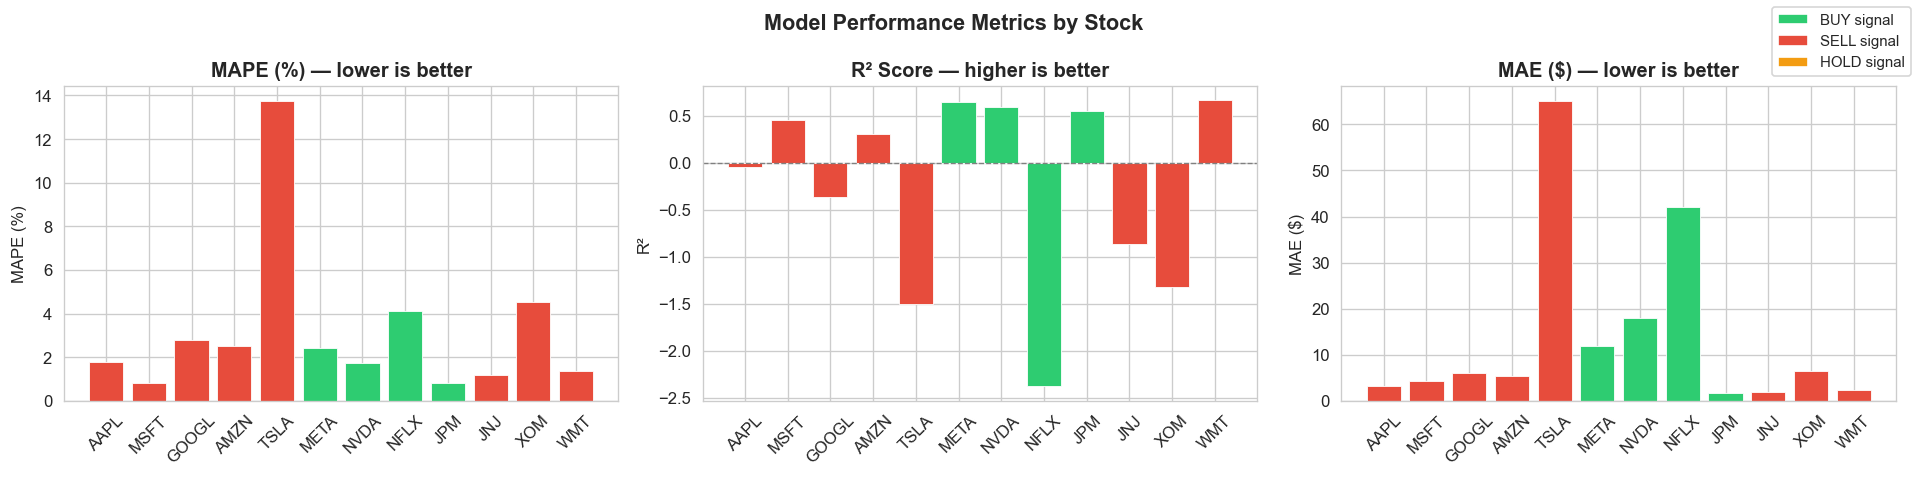

In [11]:
# Metrics comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

mapes  = [results[s]['mape'] for s in stocks]
r2s    = [results[s]['r2']   for s in stocks]
maes   = [results[s]['mae']  for s in stocks]

bar_colors = ['#2ecc71' if results[s]['signal'] == 'BUY'
               else '#e74c3c' if results[s]['signal'] == 'SELL'
               else '#f39c12' for s in stocks]

axes[0].bar(stocks, mapes, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('MAPE (%) — lower is better', fontweight='bold')
axes[0].set_ylabel('MAPE (%)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(stocks, r2s, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('R² Score — higher is better', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(stocks, maes, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[2].set_title('MAE ($) — lower is better', fontweight='bold')
axes[2].set_ylabel('MAE ($)')
axes[2].tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='BUY signal'),
    Patch(facecolor='#e74c3c', label='SELL signal'),
    Patch(facecolor='#f39c12', label='HOLD signal')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.suptitle('Model Performance Metrics by Stock', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Actual vs Predicted Plots (All Stocks)

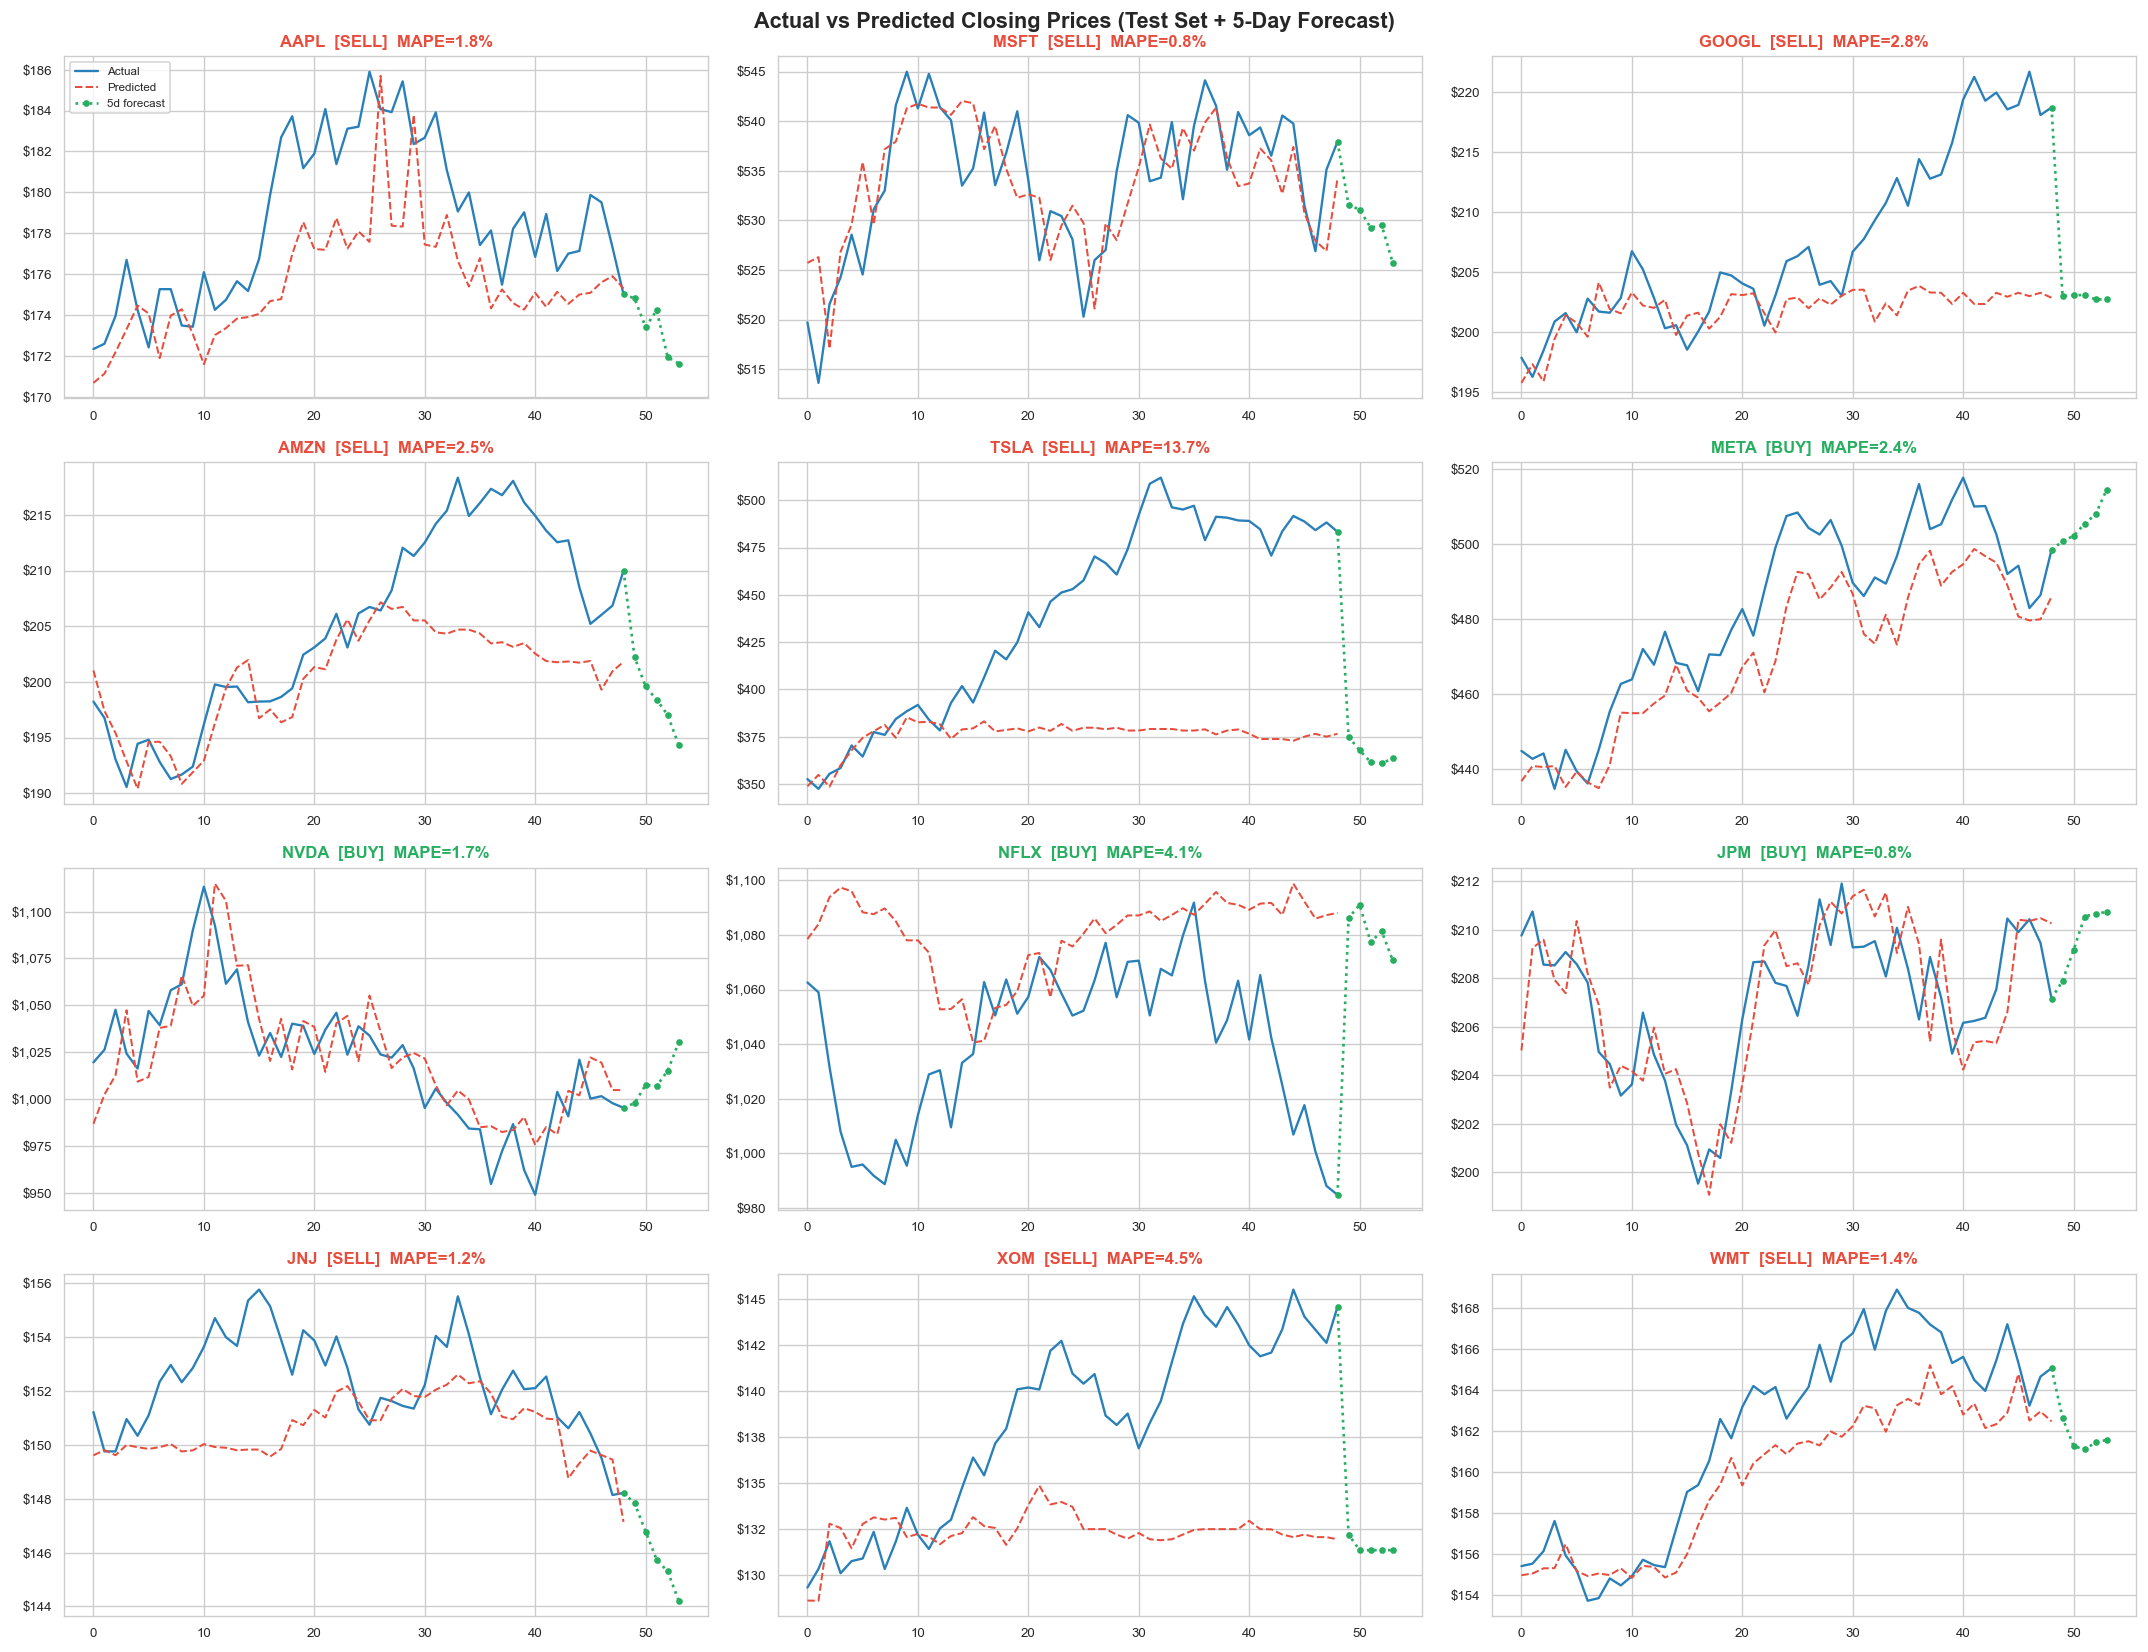

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    r   = results[stock]
    ax  = axes[i]
    idx = range(len(r['y_test']))

    ax.plot(idx, r['y_test'], label='Actual',    color='#2980b9', linewidth=1.4)
    ax.plot(idx, r['y_pred'], label='Predicted', color='#e74c3c', linewidth=1.2, linestyle='--')

    # Forecast extension
    fcast_idx = range(len(r['y_test']) - 1, len(r['y_test']) + 5)
    fcast_y   = [r['y_test'][-1]] + r['next5']
    ax.plot(fcast_idx, fcast_y, color='#27ae60', linewidth=1.6,
            linestyle=':', marker='o', markersize=3, label='5d forecast')

    signal_color = '#27ae60' if r['signal'] == 'BUY' else '#e74c3c' if r['signal'] == 'SELL' else '#f39c12'
    ax.set_title(f"{stock}  [{r['signal']}]  MAPE={r['mape']:.1f}%",
                 fontsize=10, fontweight='bold', color=signal_color)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Actual vs Predicted Closing Prices (Test Set + 5-Day Forecast)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. 5-Day Price Forecast

In [13]:
# 5-day forecast table
forecast_df = pd.DataFrame(index=stocks)
forecast_df['Current ($)'] = [round(results[s]['current'], 2) for s in stocks]

for d in range(1, 6):
    forecast_df[f'Day {d} ($)'] = [round(results[s]['next5'][d-1], 2) for s in stocks]

forecast_df['5d Change (%)'] = [round(results[s]['change_pct'], 2) for s in stocks]
forecast_df['Signal'] = [results[s]['signal'] for s in stocks]

def style_row(row):
    if row['Signal'] == 'BUY':  return ['background-color: #d4edda'] * len(row)
    if row['Signal'] == 'SELL': return ['background-color: #f8d7da'] * len(row)
    return ['background-color: #fff3cd'] * len(row)

forecast_df.style.apply(style_row, axis=1)

,Current ($),Day 1 ($),Day 2 ($),Day 3 ($),Day 4 ($),Day 5 ($),5d Change (%),Signal
AAPL,175.010000,174.800000,173.400000,174.220000,171.930000,171.620000,-1.940000,SELL
MSFT,537.930000,531.570000,531.080000,529.270000,529.500000,525.730000,-2.270000,SELL
GOOGL,218.730000,203.000000,203.090000,203.090000,202.730000,202.730000,-7.320000,SELL
AMZN,209.980000,202.210000,199.590000,198.390000,197.030000,194.310000,-7.460000,SELL
TSLA,483.320000,375.040000,367.780000,361.620000,360.920000,363.600000,-24.770000,SELL
META,498.370000,500.710000,502.110000,505.360000,507.890000,514.470000,3.230000,BUY
NVDA,995.330000,997.800000,1007.440000,1006.950000,1015.050000,1030.310000,3.510000,BUY
NFLX,984.800000,1086.200000,1091.040000,1077.330000,1081.380000,1070.670000,8.720000,BUY
JPM,207.170000,207.900000,209.170000,210.550000,210.680000,210.740000,1.720000,BUY
JNJ,148.220000,147.830000,146.780000,145.740000,145.300000,144.210000,-2.700000,SELL


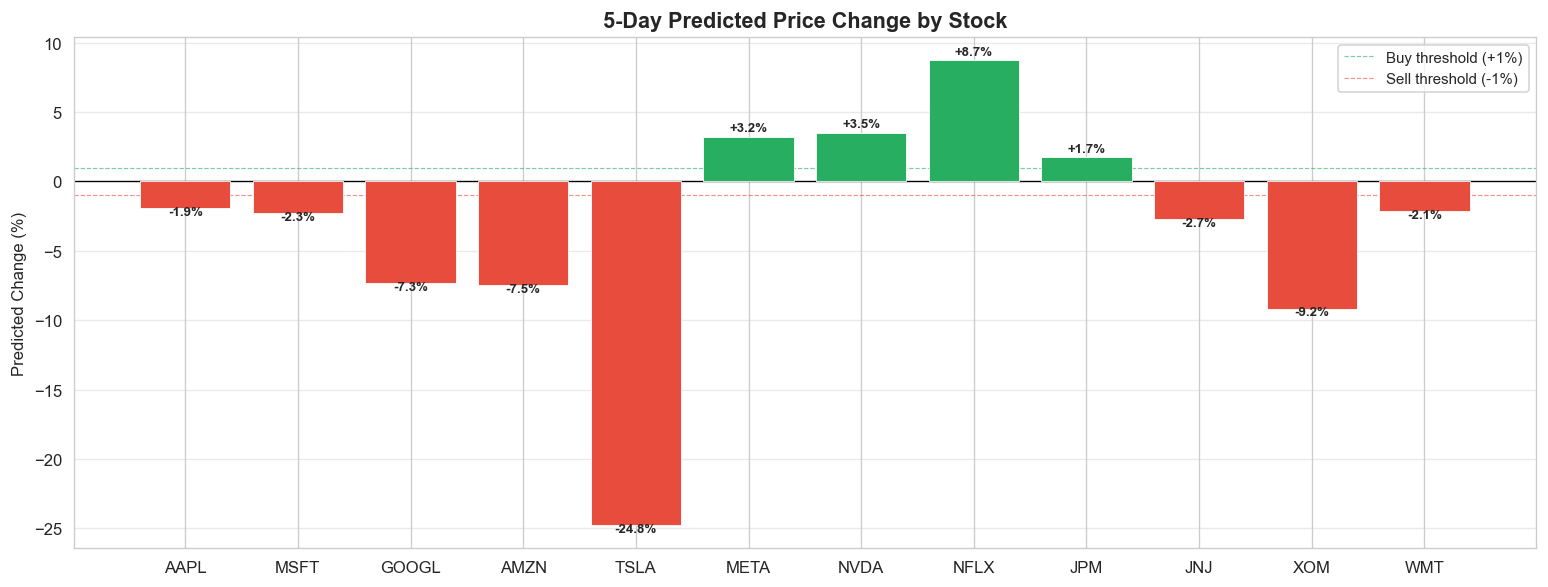

In [14]:
# 5-day forecast bar chart
changes = [results[s]['change_pct'] for s in stocks]
bar_colors = ['#27ae60' if c > 1 else '#e74c3c' if c < -1 else '#f39c12' for c in changes]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(stocks, changes, color=bar_colors, edgecolor='white', linewidth=0.5, zorder=3)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1,  color='#27ae60', linestyle='--', linewidth=0.7, alpha=0.6, label='Buy threshold (+1%)')
ax.axhline(-1, color='#e74c3c', linestyle='--', linewidth=0.7, alpha=0.6, label='Sell threshold (-1%)')

for bar, val in zip(bars, changes):
    ypos = bar.get_height() + 0.2 if val >= 0 else bar.get_height() - 0.7
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('5-Day Predicted Price Change by Stock', fontsize=13, fontweight='bold')
ax.set_ylabel('Predicted Change (%)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

## 9. Feature Importance (Top Stocks)

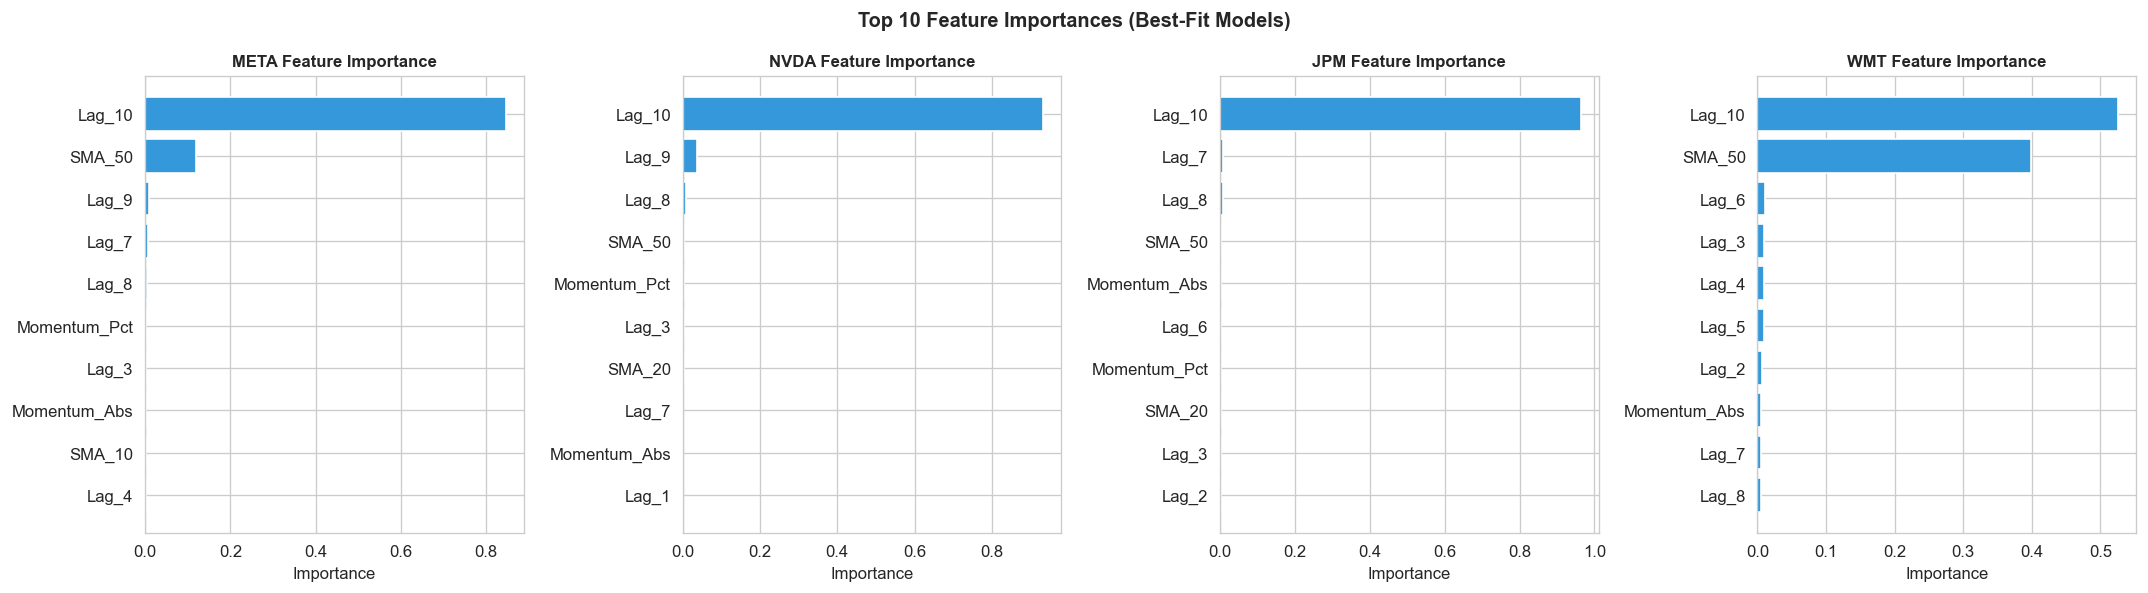

In [15]:
feature_names = ([f'Lag_{i+1}' for i in range(LOOKBACK)] +
                 ['SMA_10', 'SMA_20', 'SMA_50', 'Momentum_Abs', 'Momentum_Pct'])

top_stocks = ['META', 'NVDA', 'JPM', 'WMT']  # best R² models

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, stock in enumerate(top_stocks):
    imp = results[stock]['model'].feature_importances_
    sorted_idx = np.argsort(imp)[::-1]
    axes[i].barh([feature_names[j] for j in sorted_idx[:10]],
                 [imp[j] for j in sorted_idx[:10]],
                 color='#3498db', edgecolor='white')
    axes[i].invert_yaxis()
    axes[i].set_title(f'{stock} Feature Importance', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Importance')

plt.suptitle('Top 10 Feature Importances (Best-Fit Models)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Residual Analysis

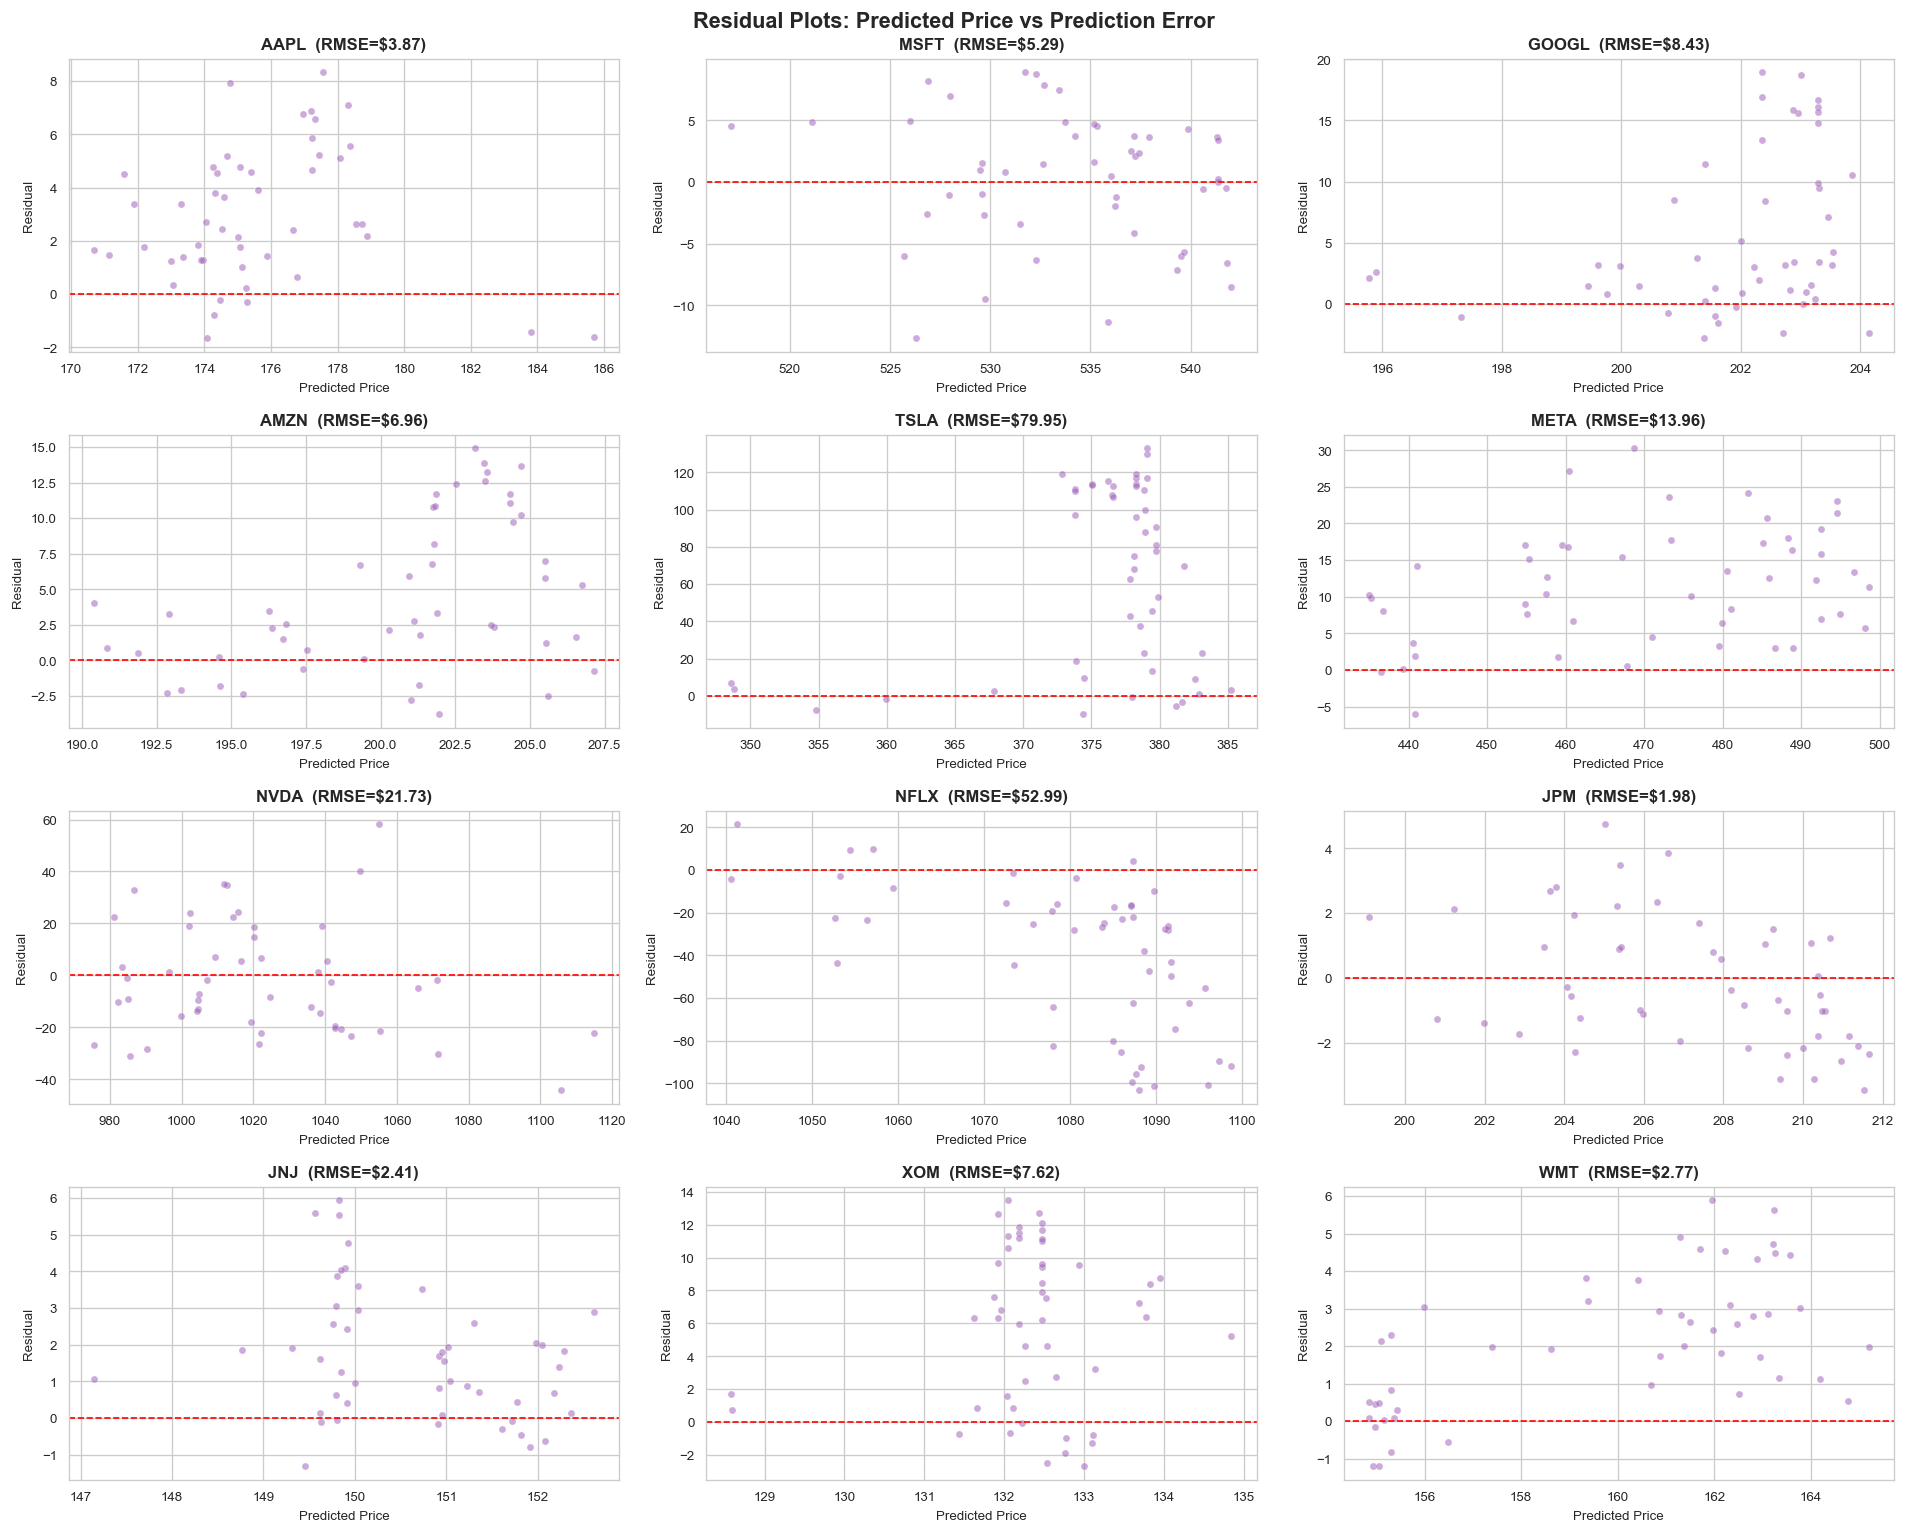

In [16]:
fig, axes = plt.subplots(4, 3, figsize=(16, 13))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    r = results[stock]
    residuals = r['y_test'] - r['y_pred']
    ax = axes[i]
    ax.scatter(r['y_pred'], residuals, alpha=0.5, s=18,
               color='#9b59b6', edgecolors='white', linewidths=0.3)
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_title(f'{stock}  (RMSE=${r["rmse"]:.2f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Price', fontsize=8)
    ax.set_ylabel('Residual', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle('Residual Plots: Predicted Price vs Prediction Error', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Signal Summary & Conclusion

In [17]:
buy_stocks  = [s for s in stocks if results[s]['signal'] == 'BUY']
sell_stocks = [s for s in stocks if results[s]['signal'] == 'SELL']
hold_stocks = [s for s in stocks if results[s]['signal'] == 'HOLD']

print('=' * 55)
print('      5-DAY ML PREDICTION SIGNAL SUMMARY')
print('=' * 55)
print(f'\n🟢 BUY  ({len(buy_stocks)} stocks):')
for s in buy_stocks:
    print(f'   {s:5s}  Current: ${results[s]["current"]:>8.2f}  →  Forecast: ${results[s]["next5"][-1]:>8.2f}  ({results[s]["change_pct"]:+.2f}%)')

print(f'\n🔴 SELL ({len(sell_stocks)} stocks):')
for s in sell_stocks:
    print(f'   {s:5s}  Current: ${results[s]["current"]:>8.2f}  →  Forecast: ${results[s]["next5"][-1]:>8.2f}  ({results[s]["change_pct"]:+.2f}%)')

if hold_stocks:
    print(f'\n🟡 HOLD ({len(hold_stocks)} stocks):')
    for s in hold_stocks:
        print(f'   {s:5s}  Current: ${results[s]["current"]:>8.2f}  →  Forecast: ${results[s]["next5"][-1]:>8.2f}  ({results[s]["change_pct"]:+.2f}%)')

print('\n' + '=' * 55)
best_r2  = max(stocks, key=lambda s: results[s]['r2'])
worst_r2 = min(stocks, key=lambda s: results[s]['r2'])
print(f'Best  model fit : {best_r2}  (R² = {results[best_r2]["r2"]:.3f})')
print(f'Worst model fit : {worst_r2}  (R² = {results[worst_r2]["r2"]:.3f})')
print('=' * 55)
print('\n⚠️  Disclaimer: ML predictions for educational use only.')
print('   Not financial advice.')

      5-DAY ML PREDICTION SIGNAL SUMMARY

🟢 BUY  (4 stocks):
   META   Current: $  498.37  →  Forecast: $  514.47  (+3.23%)
   NVDA   Current: $  995.33  →  Forecast: $ 1030.31  (+3.51%)
   NFLX   Current: $  984.80  →  Forecast: $ 1070.67  (+8.72%)
   JPM    Current: $  207.17  →  Forecast: $  210.74  (+1.72%)

🔴 SELL (8 stocks):
   AAPL   Current: $  175.01  →  Forecast: $  171.62  (-1.94%)
   MSFT   Current: $  537.93  →  Forecast: $  525.73  (-2.27%)
   GOOGL  Current: $  218.73  →  Forecast: $  202.73  (-7.32%)
   AMZN   Current: $  209.98  →  Forecast: $  194.31  (-7.46%)
   TSLA   Current: $  483.32  →  Forecast: $  363.60  (-24.77%)
   JNJ    Current: $  148.22  →  Forecast: $  144.21  (-2.70%)
   XOM    Current: $  144.58  →  Forecast: $  131.33  (-9.16%)
   WMT    Current: $  165.06  →  Forecast: $  161.56  (-2.12%)

Best  model fit : WMT  (R² = 0.664)
Worst model fit : NFLX  (R² = -2.380)

⚠️  Disclaimer: ML predictions for educational use only.
   Not financial advice.
